# Ejercicio 1 - Velocidades del viento

El pronostico de la velocidad del viento es fundamental, sobre todo por sus implicaciones en: seguridad en la aviación y la navegación, generación de energía eólica, agricultura, construcción, meteorología, recreación y deporte. Los datos suministrados, reportan diferentes mediciones que pueden explicar y permitir realizar la predicción de la velocidad del viento. En este capitulo, desarrollarenos el EDA y modelos de prediccion para la base de datos "**Velocidades de viento**". 

A continuacion, instalaremos las librerias quer seran utilizadas a lo largo del ejercicio.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# EDA y ETL 

En esta sección se desarrollarán los procesos de Análisis Exploratorio de Datos (EDA) y Extracción, Transformación y Carga (ETL) sobre la base de datos de "Velocidades de viento", con el objetivo de comprender en profundidad la estructura de los datos y analizar la problemática planteada.

In [3]:
df = pd.read_csv('/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/Parcial1ML/docs/data_treino_dv_df_2000_2010.csv')
df

,HORA (UTC),"VENTO, DIREï¿½ï¿½O HORARIA (gr) (ï¿½ (gr))","VENTO, VELOCIDADE HORARIA (m/s)",UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),TEMPERATURA Mï¿½XIMA NA HORA ANT. (AUT) (ï¿½C),TEMPERATURA Mï¿½NIMA NA HORA ANT. (AUT) (ï¿½C),"UMIDADE RELATIVA DO AR, HORARIA (%)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)","PRECIPITAï¿½ï¿½O TOTAL, HORï¿½RIO (mm)","VENTO, RAJADA MAXIMA (m/s)",PRESSï¿½O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSï¿½O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)
0,12:00,0.809017,1.8,69.0,60.0,22.6,20.7,61.0,888.2,0.0,3.8,888.2,887.7
1,13:00,0.965926,2.7,62.0,55.0,24.2,22.5,55.0,888.4,0.0,4.7,888.4,888.2
2,14:00,0.891007,2.0,56.0,50.0,25.5,24.3,51.0,888.1,0.0,4.9,888.4,888.1
3,15:00,0.848048,2.5,52.0,44.0,27.4,25.0,44.0,887.4,0.0,5.8,888.1,887.4
4,16:00,0.224951,2.4,50.0,43.0,27.1,25.5,46.0,886.5,0.0,5.8,887.4,886.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87688,19:00,-0.615661,5.6,83.0,78.0,21.8,21.1,80.0,879.1,0.0,12.3,879.8,879.1
87689,20:00,-0.469472,4.9,84.0,79.0,21.7,21.0,84.0,879.2,0.0,9.9,879.2,878.9
87690,21:00,-0.484810,4.5,86.0,82.0,21.2,20.6,86.0,879.7,0.0,8.9,879.8,879.2
87691,22:00,-0.484810,3.2,88.0,85.0,20.6,20.2,88.0,880.5,0.0,8.0,880.5,879.6


Se observa un total de 87,693 muestras y 13 columnas, que contienen información relacionada con variables meteorológicas como humedad, presión, precipitación, temperatura y viento (incluyendo velocidad, dirección y ráfaga máxima). Además, se cuenta con una variable temporal registrada en formato horario militar.

Con el fin de facilitar el manejo y análisis de los datos, se procederá a reducir la longitud de los nombres de las variables, manteniendo su significado original pero mejorando la legibilidad y eficiencia en el procesamiento.

#### Renombramiento de columnas

A continuación se muestra la correspondencia entre los nombres originales del dataset y los nuevos nombres utilizados para facilitar el análisis:

| Nombre original                                                      | Nuevo nombre         |
|----------------------------------------------------------------------|----------------------|
| HORA (UTC)                                                           | `hora`               |
| VENTO, DIREÇÃO HORARIA (gr)                                          | `viento_dir`         |
| VENTO, VELOCIDADE HORARIA (m/s)                                      | `viento_vel`         |
| UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)                             | `humedad_max_ant`    |
| UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)                             | `humedad_min_ant`    |
| TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)                           | `temp_max_ant`       |
| TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)                           | `temp_min_ant`       |
| UMIDADE RELATIVA DO AR, HORARIA (%)                                  | `humedad_horaria`    |
| PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)               | `presion_horaria`    |
| PRECIPITAÇÃO TOTAL, HORÁRIA (mm)                                     | `precipitacion`      |
| VENTO, RAJADA MAXIMA (m/s)                                           | `viento_rafaga_max`  |
| PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)                      | `presion_max_ant`    |
| PRESSÃO ATMOSFERICA MIN.NA HORA ANT. (AUT) (mB)                      | `presion_min_ant`    |


In [4]:
# Renombramos los nombres de cada columna 
df.columns = [
    'hora',
    'viento_dir',
    'viento_vel',
    'humedad_max_ant',
    'humedad_min_ant',
    'temp_max_ant',
    'temp_min_ant',
    'humedad_horaria',
    'presion_horaria',
    'precipitacion',
    'viento_rafaga_max',
    'presion_max_ant',
    'presion_min_ant'
    ]

df.columns

Index(['hora', 'viento_dir', 'viento_vel', 'humedad_max_ant',
       'humedad_min_ant', 'temp_max_ant', 'temp_min_ant', 'humedad_horaria',
       'presion_horaria', 'precipitacion', 'viento_rafaga_max',
       'presion_max_ant', 'presion_min_ant'],
      dtype='object')

Una vez realizado el cambio de nombres de las variables, se dará inicio al análisis exploratorio para comprender mejor la base de datos e identificar posibles patrones o relaciones entre las variables.

#### Descripción de tipos de variables

En esta sección se llevará a cabo un análisis exploratorio de datos con el objetivo de comprender la estructura del conjunto de datos, identificar patrones, detectar posibles anomalías y seleccionar variables relevantes para el desarrollo de modelos predictivos.

In [5]:
var = [
    'hora',
    'viento_dir',
    'viento_vel',
    'humedad_max_ant',
    'humedad_min_ant',
    'temp_max_ant',
    'temp_min_ant',
    'humedad_horaria',
    'presion_horaria',
    'precipitacion',
    'viento_rafaga_max',
    'presion_max_ant',
    'presion_min_ant'
    ]

df[var].describe().T

,count,mean,std,min,25%,50%,75%,max
viento_dir,87693.0,0.405810,0.686247,-1.0,-0.156434,0.788011,0.970296,1.0
viento_vel,87693.0,2.466192,1.313968,0.0,1.500000,2.400000,3.400000,10.0
humedad_max_ant,87693.0,69.058465,19.640222,12.0,54.000000,72.000000,87.000000,100.0
humedad_min_ant,87693.0,63.176194,20.166336,10.0,48.000000,64.000000,80.000000,98.0
temp_max_ant,87693.0,21.921264,3.721386,9.2,19.200000,21.400000,24.700000,35.3
temp_min_ant,87693.0,20.684570,3.513744,8.4,18.400000,20.200000,23.100000,34.4
humedad_horaria,87693.0,66.146682,19.992327,10.0,51.000000,68.000000,84.000000,99.0
presion_horaria,87693.0,887.251925,4.012404,863.4,885.300000,887.200000,889.100000,1023.5
precipitacion,87693.0,0.160907,1.307515,0.0,0.000000,0.000000,0.000000,70.8
viento_rafaga_max,87693.0,5.161076,2.311157,0.0,3.400000,5.000000,6.800000,24.3


En la tabla anterior se presentan diversas estadísticas descriptivas de la base de datos, incluyendo la media, desviación estándar, valores mínimos y máximos, así como los cuartiles (25, 50 y 75%) y el conteo total de observaciones por variable.

Entre los valores destacados, se observa que la temperatura promedio se encuentra entre **20 °C** y **21 °C**, alcanzando un máximo de **35 °C**. Por otro lado, la velocidad del viento suele ser baja en general; sin embargo, se registró un valor máximo de **24.3 m/s** en las ráfagas máximas, lo cual podría representar un indicio del potencial aprovechamiento de este recurso energético en determinadas condiciones.

In [6]:
df.isnull().sum()

hora                 0
viento_dir           0
viento_vel           0
humedad_max_ant      0
humedad_min_ant      0
temp_max_ant         0
temp_min_ant         0
humedad_horaria      0
presion_horaria      0
precipitacion        0
viento_rafaga_max    0
presion_max_ant      0
presion_min_ant      0
dtype: int64

Al analizar la base de datos, observamos que no se presentan datos faltantes en ninguna de las variables utilizadas para el análisis. Esto implica que no es necesario aplicar técnicas de imputación ni eliminar registros, por lo que podemos trabajar con la totalidad de la información suministrada.

El objetivo principal de este proyecto es diseñar un modelo de regresión que permita comprender el comportamiento de la velocidad del viento a partir de las variables explicativas incluidas en el conjunto de datos. Para lograr este objetivo, es fundamental analizar la relación entre las variables independientes y la variable de respuesta.

En la siguiente sección se realizará un análisis exploratorio de los datos con el fin de identificar patrones, tendencias y posibles relaciones entre las variables que puedan contribuir al desempeño del modelo de predicción.

#### Analisis de correlacion entre variables explicativas y de respuesta

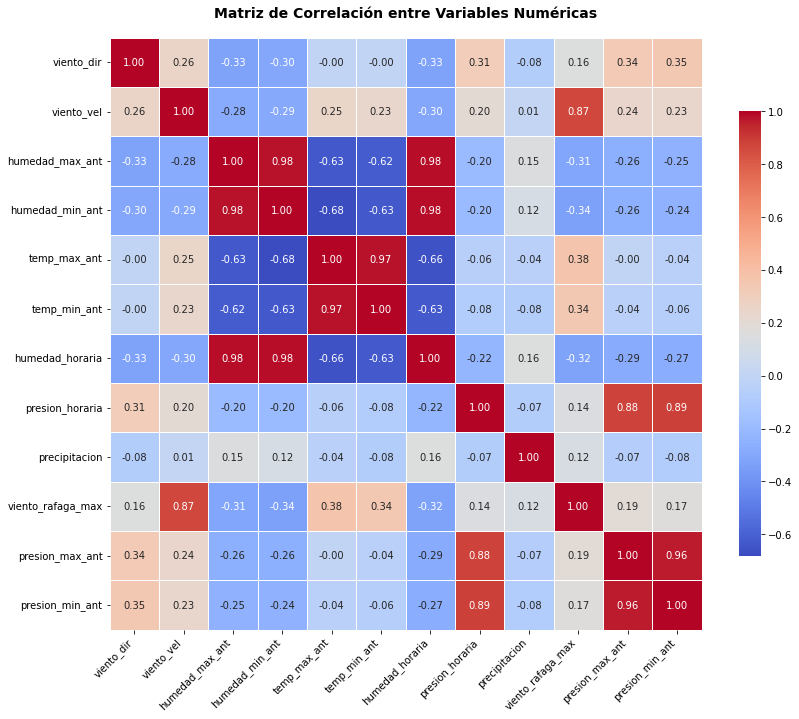

In [5]:
# Calcular la correlación
corr_matrix = df.corr()

# Crear figura más grande
plt.figure(figsize=(12, 10))

# Dibujar heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                 # Mostrar los valores
    fmt=".2f",                  # Formato de los números
    cmap='coolwarm',            # Mapa de color
    square=True,                # Cuadrícula cuadrada
    cbar_kws={"shrink": 0.75},  # Barra de color más pequeña
    linewidths=0.5,             # Líneas entre celdas
    annot_kws={"size": 10}      # Tamaño del texto de los valores
)

# Ajustes de etiquetas
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Título general
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

En la figura anterior, se presenta un mapa de calor que muestra el coeficiente de correlación entre las variables numéricas del conjunto de datos. A partir de esta visualización, podemos destacar que la mayoría de las variables presentan coeficientes de correlación relativamente bajos, oscilando entre 0 y 0.4.

Sin embargo, algunas variables muestran correlaciones superiores a 0.8. Este comportamiento se debe principalmente a que dichas variables fueron generadas a través de técnicas de **feature engineering**. Por ejemplo, a partir de variables generales como humedad, presión, temperatura y viento, se derivaron nuevas variables como máximos, mínimos, dirección del viento y ráfaga máxima. Estas derivaciones naturalmente comparten información con las variables originales, generando así una alta correlación entre ellas.

A continuación, observaremos el coeficiente de correlación de todas las variables con respecto a la variable objetivo: velocidad del viento, con el fin de identificar aquellas variables que podrían tener mayor influencia en el modelo de predicción.

In [6]:
df.corr()['viento_vel'].sort_values(ascending=False)

viento_vel           1.000000
viento_rafaga_max    0.868279
viento_dir           0.256588
temp_max_ant         0.247706
presion_max_ant      0.242446
presion_min_ant      0.231584
temp_min_ant         0.231472
presion_horaria      0.204031
precipitacion        0.009466
humedad_max_ant     -0.282787
humedad_min_ant     -0.291752
humedad_horaria     -0.301358
Name: viento_vel, dtype: float64

Se evidencia una correlación significativa entre la variable de respuesta **"viento_vel"** y diversas variables independientes del conjunto de datos. Para este análisis, se seleccionarán las variables **"vel_rafaga_max"**, **"humedad_horaria"**, **"presion_max_ant"** y **"temp_max_ant"**, ya que presentan los niveles más altos de correlación con la variable objetivo.

Esta selección no solo se basa en la magnitud del coeficiente de correlación, sino también en la representatividad de estas variables dentro de sus respectivas categorías. Es decir, variables como presión, temperatura, humedad y viento cuentan con múltiples subcategorías que derivan de una misma fuente de medición. Estas fueron generadas previamente mediante técnicas de feature engineering a partir de datos básicos.

Por esta razón, las variables seleccionadas actúan como representantes de su grupo, y las altas correlaciones observadas entre subcategorías pueden explicarse por el hecho de provenir de una misma categoría física o métrica.

En la siguiente sección, analizaremos el comportamiento de la variable objetivo respecto a estas variables seleccionadas, con el fin de explorar patrones y relaciones útiles para el desarrollo del modelo de regresión.

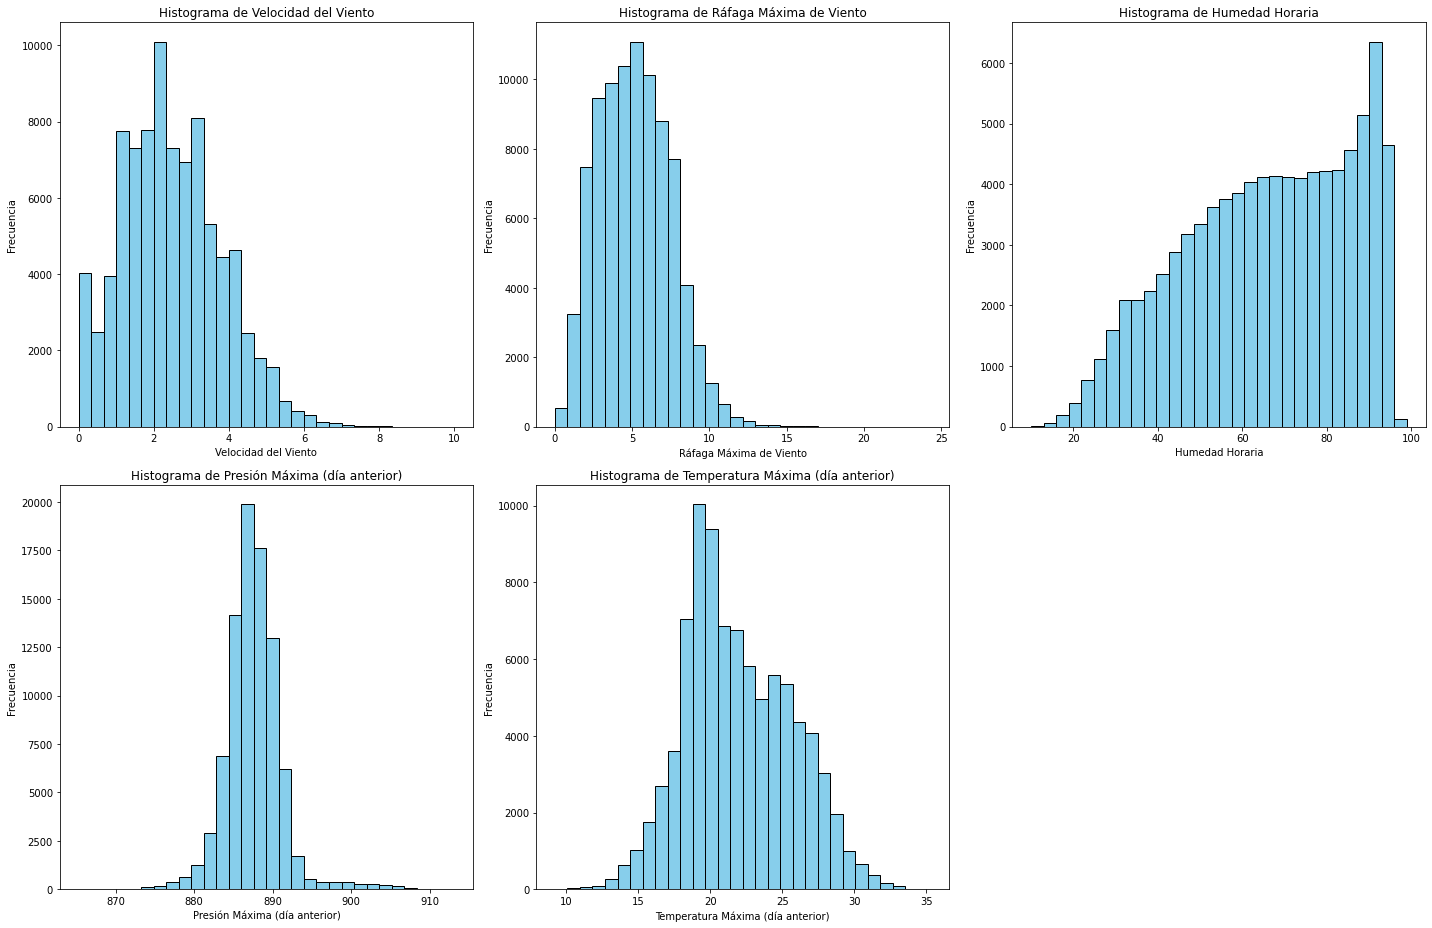

In [6]:
# Variables a graficar
variables = ['viento_vel', 'viento_rafaga_max', 'humedad_horaria', 'presion_max_ant', 'temp_max_ant']
titulos = [
    'Velocidad del Viento',
    'Ráfaga Máxima de Viento',
    'Humedad Horaria',
    'Presión Máxima (día anterior)',
    'Temperatura Máxima (día anterior)'
]

# Crear figura con subplots (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(20, 13))  # Tamaño ajustado

# Aplanamos los ejes para facilitar el indexado
axes = axes.flatten()

# Graficar cada variable
for i, var in enumerate(variables):
    axes[i].hist(df[var], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {titulos[i]}')
    axes[i].set_xlabel(titulos[i])
    axes[i].set_ylabel('Frecuencia')

# Eliminar el subplot vacío (último en posición 6 si solo usamos 5)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En la figura anterior se observa la distribución de frecuencia de las variables explicativas y la variable de respuesta. Se puede apreciar que variables como presión máxima, temperatura máxima, ráfaga máxima y velocidad del viento tienden a presentar una forma similar a una distribución normal.

En particular, la ráfaga máxima y la velocidad del viento muestran un sesgo hacia la derecha, lo cual indica una mayor concentración de valores bajos con una cola extendida hacia valores altos. En contraste, la temperatura máxima y la presión máxima presentan distribuciones más centradas y simétricas.

No obstante, la distribución de presión máxima es más estrecha y picuda, lo que sugiere una forma leptocúrtica, mientras que la distribución de temperatura máxima es más suave y se aproxima a una forma mesocúrtica.

Para caracterizar de manera más precisa la simetría y forma de estas distribuciones, se calcularán los coeficientes de asimetría (skewness) y curtosis, lo que permitirá un análisis más riguroso de su comportamiento estadístico.

#### Analisis de simetria y datos atipicos 

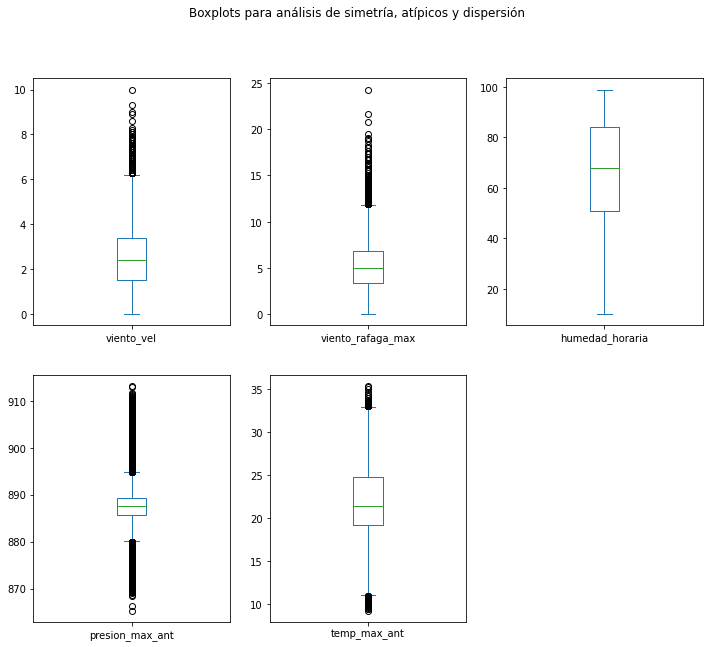

In [8]:
df[variables].plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 10), sharex=False)
plt.suptitle('Boxplots para análisis de simetría, atípicos y dispersión')
plt.show()

En la figura anterior, se presentan los boxplots de las variables previamente analizadas. En estas gráficas, se observa que las variables relacionadas con el viento (velocidad y ráfaga máxima) muestran la presencia de datos atípicos (outliers) por encima de los límites superiores, aunque sus medianas se encuentran centradas, lo que indica una distribución relativamente equilibrada en su núcleo.

En el caso de la presión máxima, la caja del boxplot es estrecha, lo que sugiere una baja dispersión: la mayoría de los valores se concentran alrededor de un rango específico. La temperatura máxima presenta un comportamiento similar, aunque en este caso se observan outliers tanto por encima como por debajo de los límites del rango intercuartílico, lo cual indica mayor variabilidad en los extremos.

Por otro lado, la variable humedad horaria no presenta valores atípicos visibles, pero muestra un rango intercuartílico más amplio, lo cual revela una mayor variabilidad en su distribución en comparación con las demás variables.

Estos boxplots permiten corroborar las observaciones realizadas previamente a partir de los histogramas, validando así las características básicas de la distribución de cada variable.

A continuación, para tener una mejor comprensión de la simetría y forma de las distribuciones, se realizará un análisis de asimetría (skewness) y curtosis (kurtosis), lo que permitirá evaluar si las variables presentan sesgo (asimetría) o colas pesadas (curtosis) en su distribución.

In [9]:
df[variables].skew()

viento_vel           0.370276
viento_rafaga_max    0.411720
humedad_horaria     -0.349514
presion_max_ant      1.024888
temp_max_ant         0.263013
dtype: float64

En el análisis de skewness de las variables meteorológicas, se observa que la mayoría presentan distribuciones ligeramente asimétricas, cercanas a la normalidad. Las variables viento_vel, viento_rafaga_max y temp_max_ant muestran una asimetría positiva leve, lo cual indica que sus distribuciones tienen una ligera cola hacia valores más altos, pero en general no requieren transformaciones.

Por otro lado, la variable humedad_horaria presenta una asimetría negativa ligera, lo que sugiere que hay una mayor concentración de valores altos (es decir, alta humedad), con una cola hacia valores bajos. Esta también se considera aceptablemente simétrica para la mayoría de los modelos.

Sin embargo, la variable presion_max_ant muestra una asimetría positiva más marcada (skewness > 1), lo que indica una distribución más sesgada hacia la derecha.


In [112]:
from scipy.stats import kurtosis

df[variables].kurtosis()

viento_vel          -0.105828
viento_rafaga_max    0.113629
humedad_horaria     -0.890021
presion_max_ant      5.819274
temp_max_ant        -0.417240
dtype: float64

El análisis de curtosis revela que la mayoría de las variables meteorológicas presentan distribuciones cercanas a lo normal. Por ejemplo, viento_vel y viento_rafaga_max tienen valores de curtosis muy próximos a cero, lo que indica que sus distribuciones son mesocúrticas, es decir, similares a una distribución normal, sin una presencia destacada de valores extremos ni colas inusuales. Del mismo modo, temp_max_ant muestra una ligera curtosis negativa, lo que sugiere una distribución algo más aplanada (platicúrtica), pero que no representa una preocupación significativa.

Por otro lado, humedad_horaria también presenta curtosis negativa más pronunciada, lo cual indica una distribución aún más aplanada, con menor frecuencia de valores extremos. Esta condición no suele ser problemática, pero puede implicar menor variabilidad en los valores fuera del promedio.

Sin embargo, la variable presion_max_ant destaca notablemente con una curtosis de 5.82, lo que la clasifica como leptocúrtica. Esto indica una alta concentración de datos alrededor de la media, pero también la presencia de colas pesadas, es decir, una mayor cantidad de valores extremos. 

A continuación, realizaremos un análisis bivariado para encontrar relaciones entre variables tanto entre la independiente (y) como las independientes (X).

In [15]:
from scipy.stats import kstest, zscore

# Especificar columnas a excluir
columnas_excluir = ['hora', 'viento_vel']

# Filtrar columnas numéricas para la prueba
columnas_ks = [col for col in df.columns if col not in columnas_excluir]

# Diccionario para guardar resultados
ks_results = {}

# Aplicar la prueba de Kolmogorov-Smirnov
for col in columnas_ks:
    try:
        # Convertir valores a numérico y eliminar nulos
        serie = pd.to_numeric(df[col], errors='coerce').dropna()
        
        # Normalizar (estandarizar) la serie
        serie_normalizada = zscore(serie)
        
        # Aplicar prueba KS comparando con distribución normal estándar
        stat, p_value = kstest(serie_normalizada, 'norm')
        
        # Guardar resultados
        ks_results[col] = {'KS Statistic': stat, 'p-value': p_value}
    except Exception as e:
        ks_results[col] = {'error': str(e)}

# Mostrar resultados
for col, resultado in ks_results.items():
    print(f"{col} → KS: {resultado.get('KS Statistic')}, p-value: {resultado.get('p-value')}")

viento_dir → KS: 0.21540831884600303, p-value: 0.0
humedad_max_ant → KS: 0.08634264138840075, p-value: 0.0
humedad_min_ant → KS: 0.0643174922561659, p-value: 7.9586675e-316
temp_max_ant → KS: 0.06696964630114338, p-value: 0.0
temp_min_ant → KS: 0.06277629820113922, p-value: 7.044432818342984e-301
humedad_horaria → KS: 0.07390455307154764, p-value: 0.0
presion_horaria → KS: 0.09381899422837137, p-value: 0.0
precipitacion → KS: 0.4791713558905091, p-value: 0.0
viento_rafaga_max → KS: 0.04162047824931375, p-value: 1.9648894696136483e-132
presion_max_ant → KS: 0.0766195106914005, p-value: 0.0
presion_min_ant → KS: 0.06052424774146559, p-value: 1.0836254044756316e-279


Con la tabla anterior, podemos observar que las variables no superan la prueba de normalidad Kolmogorov-Smirnov. 

Esto es importante de considerar a la hora de desarrollar los modelos, puestos que estos muestran sesgos y como observamos en los boxplot, algunas presentan una cantidad grande de outliers por lo que se debe considerar metodos de escalamiento de datos que sean robustos ante outliers. 

#### Análisis bivariado

<AxesSubplot:title={'center':'Velocidad promedio del viento por hora'}, xlabel='hora'>

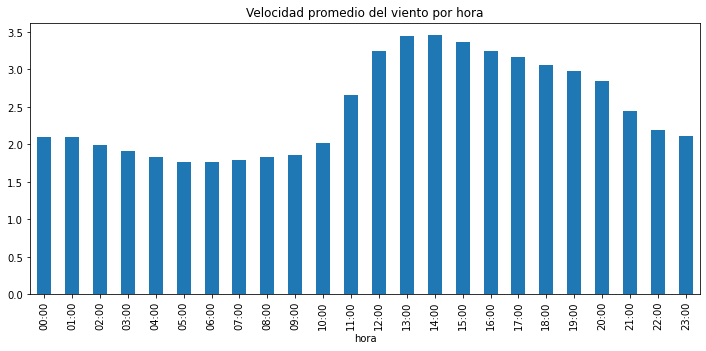

In [10]:
df.groupby('hora')['viento_vel'].mean().sort_index().plot(kind='bar', figsize=(12, 5), title='Velocidad promedio del viento por hora')

En la figura anterior, podemos observar la distribución de la velocidad media del viento (variable de respuesta, eje Y) en función de la hora. En la gráfica se observa que, en promedio, se presentan mayores velocidades entre las 11:00 y las 23:00 que entre las 00:00 y las 10:00. Adicionalmente, observamos que los puntos con menores velocidades se encuentran entre las 05:00 y las 08:00, lo que puede ser una muestra clara de la tendencia de la velocidad. 

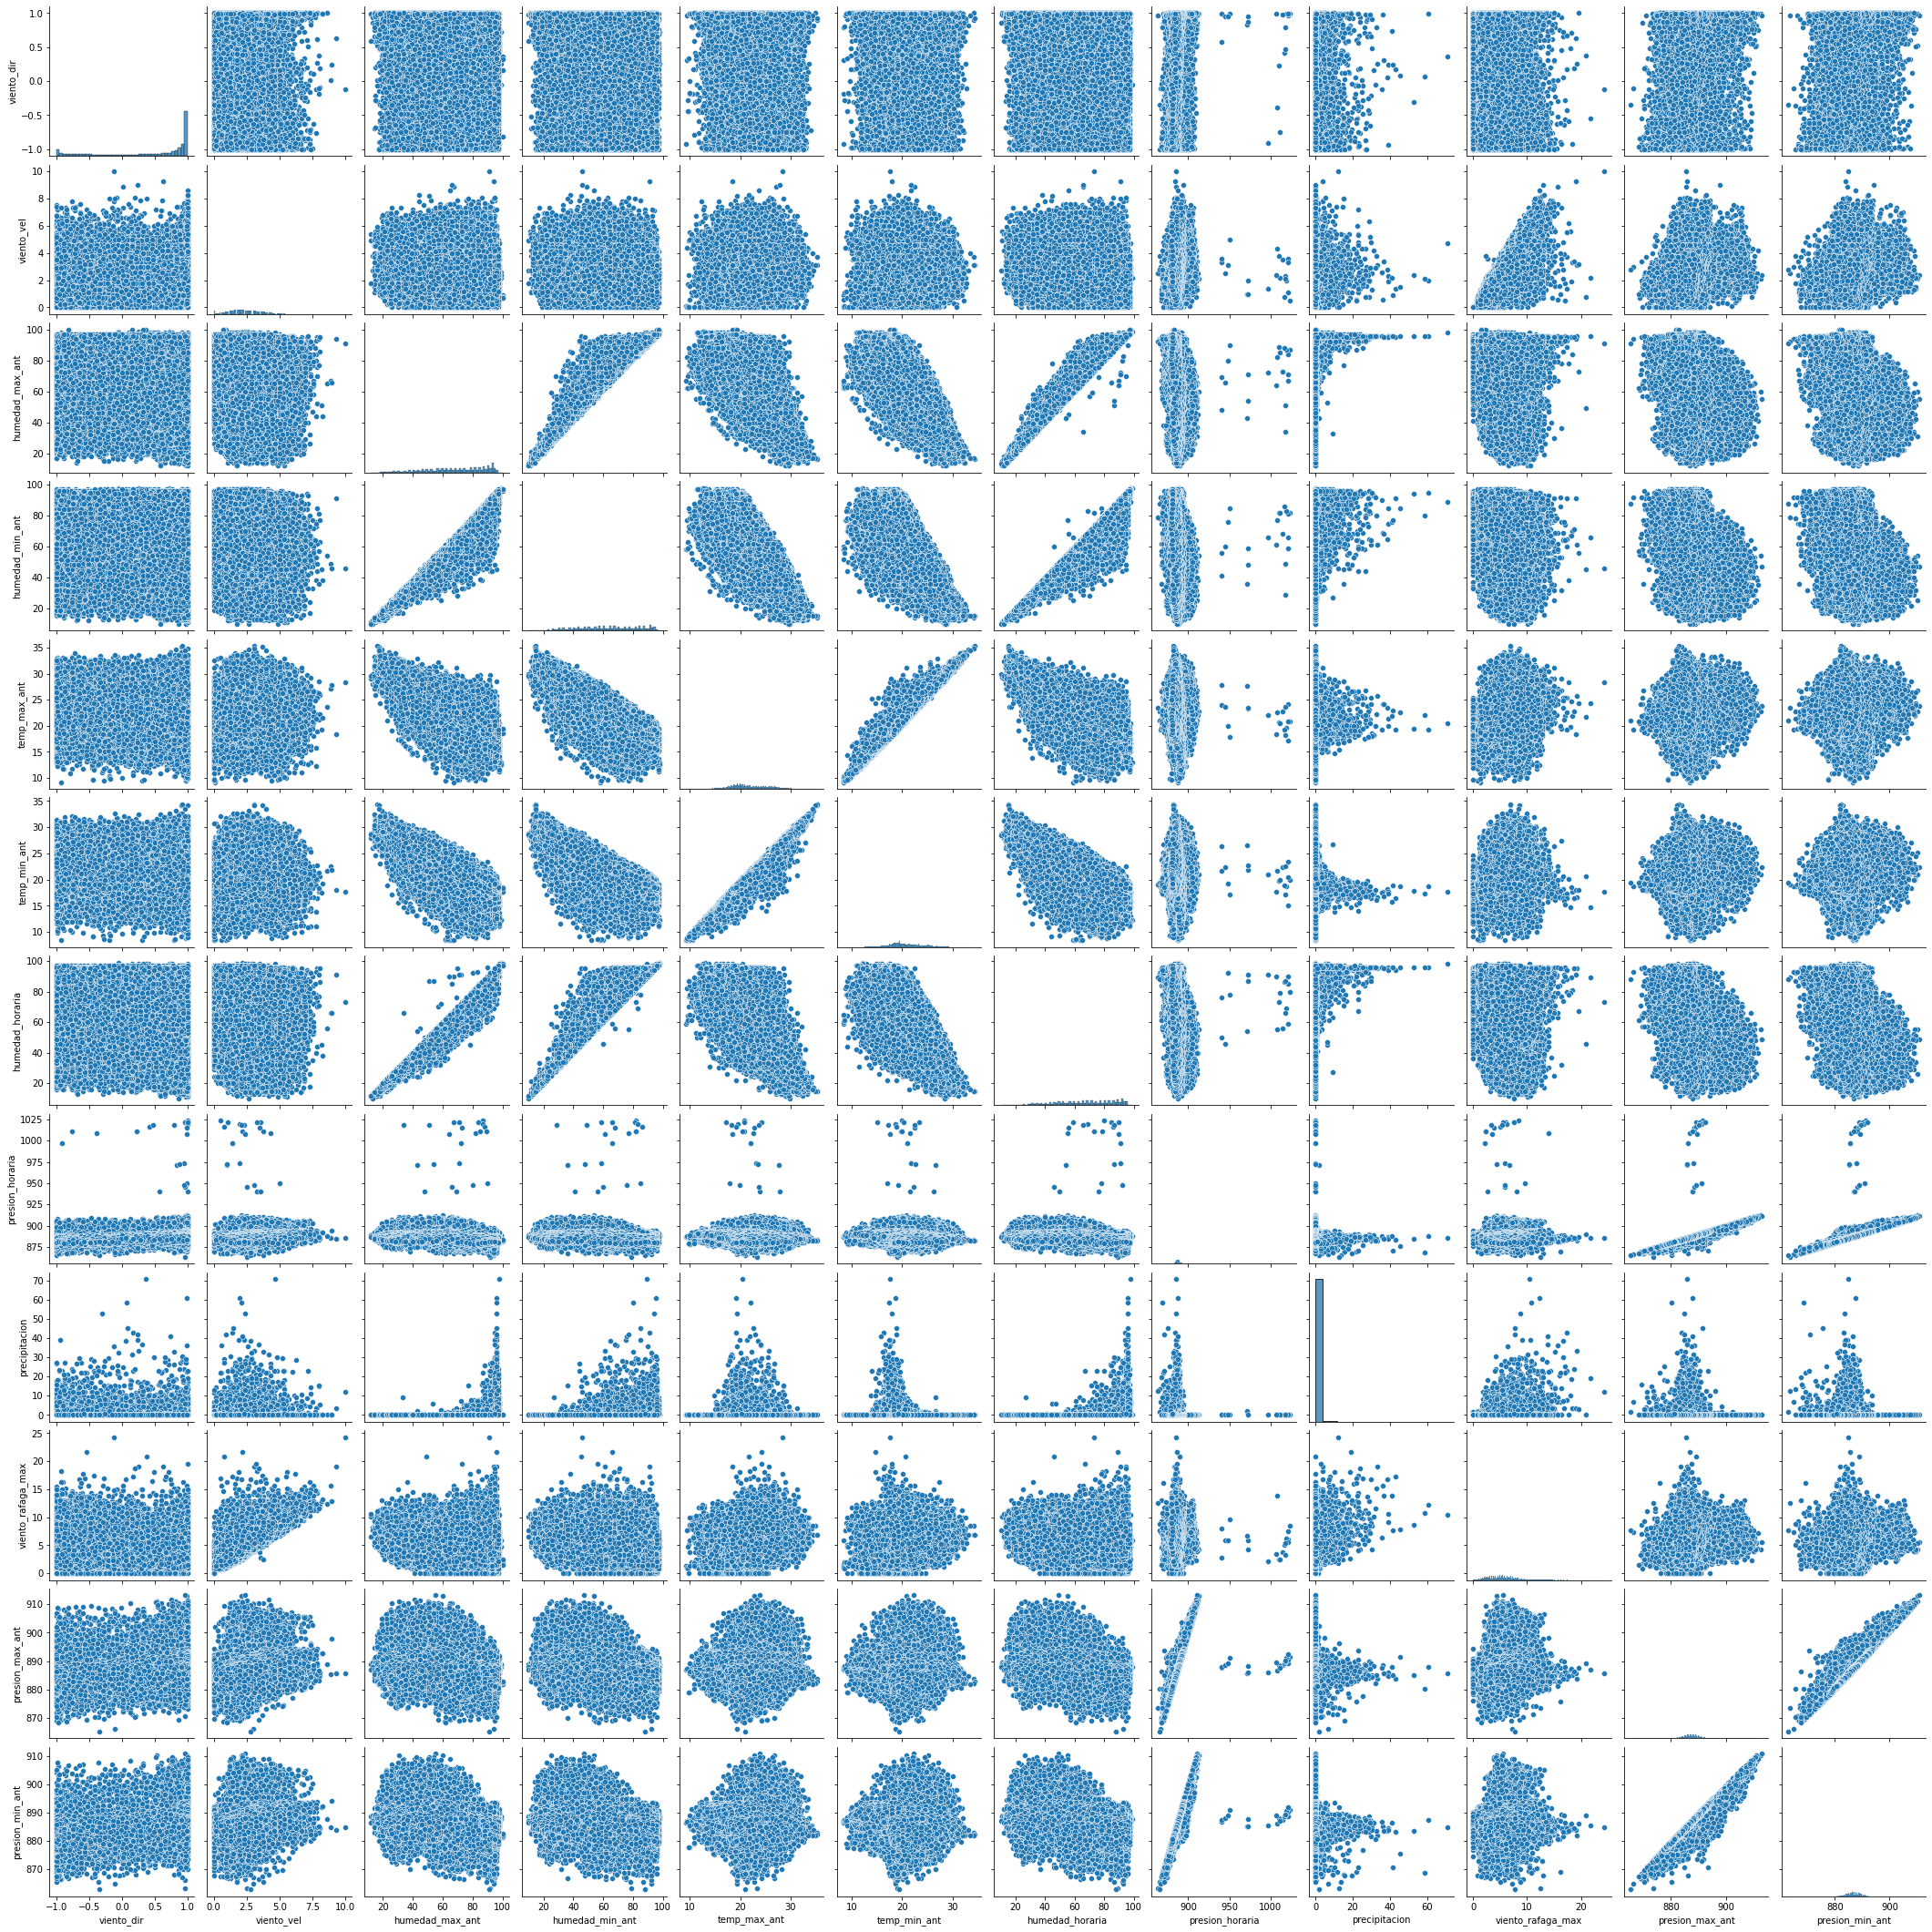

In [72]:
sns.pairplot(df)

En la figura anterior, se presenta un *pairplot* que muestra la relación entre cada par de variables analizadas. A partir de estos diagramas de dispersión, se identifican las siguientes relaciones que merecen un análisis más detallado:

-   `humedad_horaria` vs `temp_max_ant`
-   `humedad_horaria` vs `presion_max_ant`
-   `precipitacion` vs `temp_max_ant`
-   `precipitacion` vs `humedad_horaria`
-   `presion_max_ant` vs `temp_max_ant`
-   `viento_vel` vs `presion_max_ant`

A continuación, se procederá a examinar estas relaciones específicas con mayor profundidad.

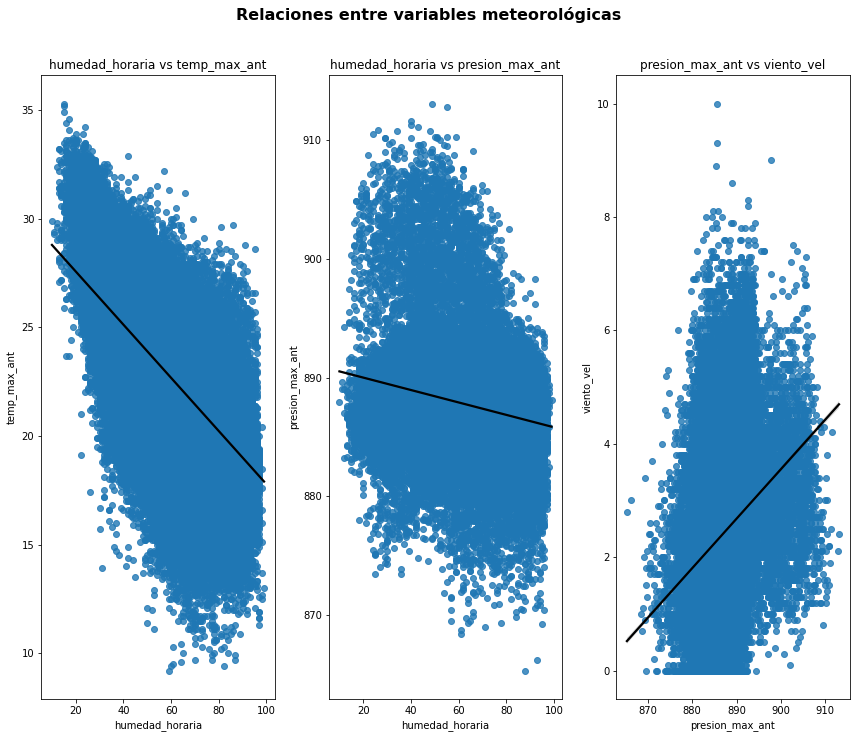

In [117]:
# Lista de pares (x, y) a graficar
# Pares originales (los vamos a invertir en el gráfico)
pares = [
    ('humedad_horaria','temp_max_ant'),
    ('humedad_horaria', 'presion_max_ant'),
    ('presion_max_ant', 'viento_vel')
]

# Crear figura con subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(12, 10))
axes = axes.flatten()

# Graficar cada par con regplot
for i, (x, y) in enumerate(pares):
    sns.regplot(data=df, x=x, y=y, ax=axes[i],
                line_kws={'color': 'black'})
    axes[i].set_title(f'{x} vs {y}', fontsize=12)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

# Título general
plt.suptitle('Relaciones entre variables meteorológicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Relación entre humedad, temperatura y presión**

En el gráfico anterior se observa la relación entre la humedad horaria, la temperatura y la presión máxima. Mediante el regplot, se identifica una relación inversamente proporcional entre la humedad y estas dos variables: a medida que la humedad aumenta, tanto la temperatura como la presión tienden a disminuir. Este hallazgo resulta relevante, ya que podría influir en la predicción de la velocidad del viento.

Adicionalmente, se evidencia una relación directamente proporcional entre la presión y la velocidad del viento: cuando la presión aumenta, la velocidad del viento también lo hace. Estas correlaciones son determinantes para entender el comportamiento de la variable de respuesta y, por tanto, son clave para el desarrollo de la investigación.

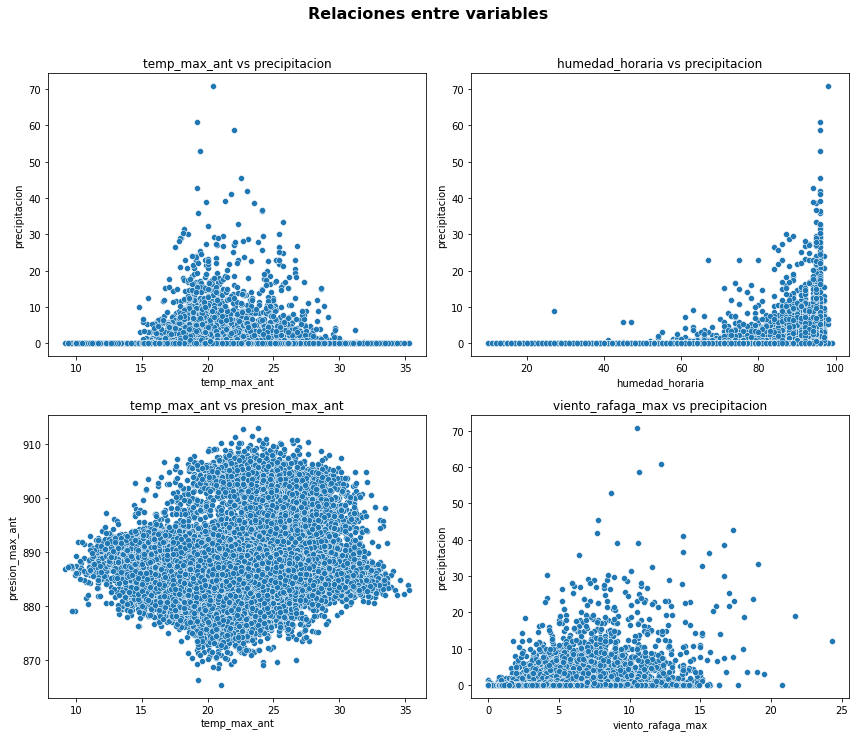

In [119]:
pares = [
    ('temp_max_ant', 'precipitacion'),
    ('humedad_horaria', 'precipitacion'),
    ('temp_max_ant', 'presion_max_ant'),
    ('viento_rafaga_max', 'precipitacion')
]

# Crear figura con subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Graficar cada par con regplot
for i, (x, y) in enumerate(pares):
    sns.scatterplot(data=df, x=x, y=y, ax=axes[i])
    axes[i].set_title(f'{x} vs {y}', fontsize=12)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

# Título general
plt.suptitle('Relaciones entre variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En la figura anterior, podemos observar relaciones y distribuciones entre las variables. La relación entre la temperatura máxima del día anterior y la precipitación no muestra un patrón claro, aunque la mayoría de los valores de precipitación se concentran cerca de cero, lo que sugiere una distribución sesgada hacia valores bajos. En el caso de la humedad horaria y la precipitación, sí se observa una relación positiva: a mayor humedad, tiende a haber más precipitación, aunque también con una alta concentración de ceros. La relación entre temperatura máxima anterior y presión máxima muestra una distribución en forma de nube densa sin una tendencia lineal clara, aunque se concentran en un rango específico de presión enytre 870 y 910. Por último, la relación entre ráfagas máximas de viento y precipitación también presenta una distribución con alta concentración en valores bajos de precipitación, pero se nota que los valores más altos de precipitación pueden asociarse con mayores ráfagas de viento.

Una vez realizado el analisis exploratorio, realizaremos el desarrollo de modelos de regresion para lograr predecir el valor de la velocidad del tiempo 

# Modelos de regresion

Para los modelos de regresion, realizaremos una lista de modelos para poder tener un abanico de opciones que mejor logren entender el comportamiento de los datos. Estos modelos son los siguientes: 

| Modelo              |
|---------------------|
| K-NN                |
| Linear Regression   |
| Ridge               |
| Lasso               |
| Decision Tree       |
| Random Forest       |
| XGBoost             |
| SVM                 |
| MLP                 |
| RNN                 |
| LSTM                |

Para garantizar que los modelos desarrollados sean generalizables, se aplicará validación cruzada (cross-validation) mediante un enfoque de ventana deslizante (sliding window). Esta metodología se selecciona debido a que las particiones respetan la tendencia temporal de la velocidad del viento, evitando así problemas de fuga de datos (data leakage) y asegurando una evaluación realista.

En primer lugar, se instalarán y cargarán las librerías necesarias para el desarrollo de los modelos. El análisis comenzará con el modelo de regresión lineal (el más básico), seguido de técnicas más avanzadas en fases posteriores.

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.stats.diagnostic import acorr_ljungbox

#### Modelo de regresion lineal

En el siguiente código se establece la configuración general para el desarrollo de los modelos, definiendo las variables independientes (predictoras) y la variable dependiente (objetivo).

Para este modelo en particular, se seleccionaron las variables analizadas durante el Análisis Exploratorio de Datos (EDA), basándose en los siguientes criterios:

Sensibilidad a multicolinealidad: El modelo requiere descartar variables altamente correlacionadas entre sí, ya que podrían explicar el mismo fenómeno (redundancia).
Relevancia estadística: Las variables elegidas demostraron patrones significativos durante el EDA.
Las variables finalmente incluidas son:

- `viento_rafaga_max`
- `humedad_horaria`
- `presion_max_ant`
- `temp_max_ant`


In [8]:
# CONFIGURACIÓN GENERAL 
features = [
        'temp_max_ant', 'humedad_horaria', 'viento_rafaga_max',
       'presion_max_ant']

target = 'viento_vel'

df = df.sort_values(by='hora').reset_index(drop=True)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

ventanas_dias = [7, 14, 21]
horas_por_dia = 24

# Crear lista vacía para guardar resultados
tabla_resultados_test = []


In [92]:
from sklearn.linear_model import LinearRegression

# RESULTADOS
resultados = []

for T_dias in ventanas_dias:
    T_horas = T_dias * horas_por_dia
    errores_val = []

    for i in range(0, len(df_train) - T_horas - horas_por_dia, horas_por_dia):
        train_data = df_train.iloc[i:i+T_horas]
        val_data = df_train.iloc[i+T_horas:i+T_horas+horas_por_dia]

        X_train = train_data[features]
        y_train = train_data[target]
        X_val = val_data[features]
        y_val = val_data[target]

        # Pipeline: escalado + modelo lineal
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', LinearRegression())
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        errores_val.append(rmse)

    promedio_rmse = np.mean(errores_val)
    resultados.append({
        'modelo': 'LinearRegression',
        'ventana_dias': T_dias,
        'rmse_validacion': promedio_rmse
    })
    
resultados_df = pd.DataFrame(resultados)
print(resultados_df)

             modelo  ventana_dias  rmse_validacion
0  LinearRegression             7         0.569526
1  LinearRegression            14         0.564536
2  LinearRegression            21         0.562732


Para agilizar el proceso de desarrollo de modelos, se diseno una funcion que calcule las metricas que se desean analizar y al final se guardaran en una tabla para al finalziar el analisis, poder conlcuir a partir de ellas comprando asi todo los resuktados de cada modelo.

In [9]:
def guardar_resultados_test(modelo_nombre, y_true, y_pred, param_str="-", ventana_dias=None):
    """Calcula métricas y guarda resultados en tabla_resultados_test"""

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    ljungbox = acorr_ljungbox(y_true - y_pred, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

    tabla_resultados_test.append({
        'modelo': modelo_nombre,
        'ventana_dias': ventana_dias,
        'param': param_str,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE (%)': mape,
        'LjungBox p-value': ljungbox
    })

In [94]:
# Selección de la mejor configuración
mejor_config = resultados_df.loc[resultados_df['rmse_validacion'].idxmin()]
T_final = int(mejor_config['ventana_dias'] * horas_por_dia)

# Preparación de datos
X_train_final = df_train[features].iloc[-T_final:]
y_train_final = df_train[target].iloc[-T_final:]
X_test = df_test[features]
y_test = df_test[target]

# Modelo final: LinearRegression
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])

# Entrenamiento y predicción
final_pipeline.fit(X_train_final, y_train_final)
y_test_pred = final_pipeline.predict(X_test)

# Guardar métricas con la función creada
guardar_resultados_test(
    modelo_nombre='LinearRegression',
    y_true=y_test,
    y_pred=y_test_pred,
    param_str='-',
    ventana_dias=int(mejor_config['ventana_dias'])
)

In [95]:
pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20


#### Modelo Ridge y Lasso - regresion

Para los siguientes modelos, al ser mas complejos estos no necesitan realizar analisis de multicolinealidad a las variables ya que estos no son sensibles a la multicolinealidad. por ende, setrabajaran los todas las variables disponibles de la base de datos.


In [10]:
features = ['viento_dir','humedad_max_ant',
       'humedad_min_ant', 'temp_max_ant', 'temp_min_ant', 'humedad_horaria',
       'presion_horaria', 'precipitacion', 'viento_rafaga_max',
       'presion_max_ant', 'presion_min_ant']
target = 'viento_vel'

Teniendo en cuenta que los modelos se entrenaran de la misma forma, se diseno una funcion que logre entrenar los modelos con la metodologia planteada anteriormente. En la siguiente linea de codigo tenemos la definicion de la funcion.

In [11]:
from sklearn.model_selection import ParameterGrid


def validacion_temporal_grid(
    df_train, features, target,
    modelo_cls, modelo_nombre,
    param_grid,
    ventanas_dias=[7, 14, 21],
    horas_por_dia=24
):
    resultados = []
    grid = list(ParameterGrid(param_grid))

    for params in grid:
        for T_dias in ventanas_dias:
            T_horas = T_dias * horas_por_dia
            errores_val = []

            for i in range(0, len(df_train) - T_horas - horas_por_dia, horas_por_dia):
                train_data = df_train.iloc[i:i+T_horas]
                val_data = df_train.iloc[i+T_horas:i+T_horas+horas_por_dia]

                X_train = train_data[features]
                y_train = train_data[target]
                X_val = val_data[features]
                y_val = val_data[target]

                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('modelo', modelo_cls(**params))
                ])

                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_val)
                rmse = mean_squared_error(y_val, y_pred, squared=False)
                errores_val.append(rmse)

            promedio_rmse = np.mean(errores_val)
            resultados.append({
                'modelo': modelo_nombre,
                'params': params,
                'ventana_dias': T_dias,
                'rmse_validacion': promedio_rmse
            })

    return pd.DataFrame(resultados)


Aqui realizamos el entrenamienro y validacion de los modelos Ridge y Lasso

In [98]:
from sklearn.linear_model import Ridge, Lasso

# Grid para Ridge
param_grid_ridge = {
    'alpha': [0.01, 0.1,0.0001, 1.0],
}

resultados_ridge = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=Ridge,
    modelo_nombre='Ridge',
    param_grid=param_grid_ridge,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_ridge.sort_values('rmse_validacion'))



   modelo             params  ventana_dias  rmse_validacion
11  Ridge     {'alpha': 1.0}            21         0.543055
5   Ridge     {'alpha': 0.1}            21         0.547787
10  Ridge     {'alpha': 1.0}            14         0.548655
4   Ridge     {'alpha': 0.1}            14         0.553764
2   Ridge    {'alpha': 0.01}            21         0.554487
8   Ridge  {'alpha': 0.0001}            21         0.556653
1   Ridge    {'alpha': 0.01}            14         0.561432
7   Ridge  {'alpha': 0.0001}            14         0.564796
9   Ridge     {'alpha': 1.0}             7         0.568855
3   Ridge     {'alpha': 0.1}             7         0.580882
0   Ridge    {'alpha': 0.01}             7         0.603927
6   Ridge  {'alpha': 0.0001}             7         0.620078


In [99]:
# Grid para Lasso
param_grid_lasso = {
    'alpha': [0.01, 0.1,0.0001, 1.0],
}

resultados_lasso = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=Ridge,
    modelo_nombre='Lasso',
    param_grid=param_grid_ridge,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_lasso.sort_values('rmse_validacion'))

   modelo             params  ventana_dias  rmse_validacion
11  Lasso     {'alpha': 1.0}            21         0.543055
5   Lasso     {'alpha': 0.1}            21         0.547787
10  Lasso     {'alpha': 1.0}            14         0.548655
4   Lasso     {'alpha': 0.1}            14         0.553764
2   Lasso    {'alpha': 0.01}            21         0.554487
8   Lasso  {'alpha': 0.0001}            21         0.556653
1   Lasso    {'alpha': 0.01}            14         0.561432
7   Lasso  {'alpha': 0.0001}            14         0.564796
9   Lasso     {'alpha': 1.0}             7         0.568855
3   Lasso     {'alpha': 0.1}             7         0.580882
0   Lasso    {'alpha': 0.01}             7         0.603927
6   Lasso  {'alpha': 0.0001}             7         0.620078


Para poder evaluar el modelo, se diseno una funcion para poder generalizar el proceso de seleccion de mejores hiperparametros, entrenamienro finla y test del modelo. A esta funcion se le anadio la funcion de calculo de metricas mostrado anetriormente por lo que agiliza mucha mas el desarrollo de los siguietes modelos. 

In [12]:
def evaluar_mejores_modelos_en_test(
    resultados_validacion,
    df_train, df_test,
    features, target,
    modelos_dict,
    horas_por_dia=24
):
    mejores_configs = resultados_validacion.loc[
        resultados_validacion.groupby('modelo')['rmse_validacion'].idxmin()
    ]

    for _, fila in mejores_configs.iterrows():
        modelo_nombre = fila['modelo']
        modelo_cls = modelos_dict[modelo_nombre]
        params = fila['params']
        ventana_dias = fila['ventana_dias']
        T_final = int(ventana_dias * horas_por_dia)

        # Preparar datos
        X_train_final = df_train[features].iloc[-T_final:]
        y_train_final = df_train[target].iloc[-T_final:]
        X_test = df_test[features]
        y_test = df_test[target]

        # Modelo con parámetros óptimos
        modelo_final = modelo_cls(**params)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', modelo_final)
        ])
        pipeline.fit(X_train_final, y_train_final)
        y_pred = pipeline.predict(X_test)

        # Guardar resultados
        guardar_resultados_test(
            modelo_nombre=modelo_nombre,
            y_true=y_test,
            y_pred=y_pred,
            param_str=str(params),
            ventana_dias=ventana_dias
        )

En la siguiente linea de codigo, observamos la aplicacion de dicha funcion para los modelos de Ridge y Lasso. 

In [100]:
modelos_dict = {
    'Ridge': Ridge,
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_ridge,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict,
    horas_por_dia=24
)

modelos_dict2 = {
    'Lasso': Lasso,
}
evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_lasso,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict2,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20
1,Ridge,21,{'alpha': 1.0},0.535058,0.546119,0.738999,0.571540,36.923302,1.992728e-25
2,Lasso,21,{'alpha': 1.0},1.000467,1.498638,1.224189,-0.175762,78.444827,0.000000e+00


Podemos observar qye klos resultados entre los tres modelos desarrollados son similares. Sin embargo el modelo de Lasso ha tenenido ligeramente peor desemepeno que el lineal y Ridge.

#### Modelo KNN - regresion 

Cargamos la librerias y procedemos con el desarrollo del modelo.

In [104]:
from sklearn.neighbors import KNeighborsRegressor

# Param grid
param_grid_knn = {
    'n_neighbors': [3, 4,5,7,9],
}

resultados_knn = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=KNeighborsRegressor,
    modelo_nombre='knn',
    param_grid=param_grid_knn,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_knn.sort_values('rmse_validacion'))

   modelo              params  ventana_dias  rmse_validacion
11    knn  {'n_neighbors': 7}            21         0.666563
14    knn  {'n_neighbors': 9}            21         0.667480
8     knn  {'n_neighbors': 5}            21         0.671916
5     knn  {'n_neighbors': 4}            21         0.679698
10    knn  {'n_neighbors': 7}            14         0.688967
7     knn  {'n_neighbors': 5}            14         0.691107
13    knn  {'n_neighbors': 9}            14         0.692514
2     knn  {'n_neighbors': 3}            21         0.695857
4     knn  {'n_neighbors': 4}            14         0.698176
1     knn  {'n_neighbors': 3}            14         0.712884
6     knn  {'n_neighbors': 5}             7         0.737922
9     knn  {'n_neighbors': 7}             7         0.741038
3     knn  {'n_neighbors': 4}             7         0.742284
12    knn  {'n_neighbors': 9}             7         0.748027
0     knn  {'n_neighbors': 3}             7         0.754096


Observamos que...

In [105]:
modelos_dict3 = {
    'knn': KNeighborsRegressor,
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_knn,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict3,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20
1,Ridge,21,{'alpha': 1.0},0.535058,0.546119,0.738999,0.571540,36.923302,1.992728e-25
2,Lasso,21,{'alpha': 1.0},1.000467,1.498638,1.224189,-0.175762,78.444827,0.000000e+00
3,knn,21,{'n_neighbors': 7},0.680075,0.760734,0.872201,0.403164,49.472287,1.269213e-118


En el codigo anterior observamos las diferencias entre knn y el resto de modelos. Vemos que en algunas metricas existen mejoras, sin embargo...

#### Modelo Arboles de decision - regresion

In [107]:
from sklearn.tree import DecisionTreeRegressor

# Param grid
param_grid_dt = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

resultados_dt = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=DecisionTreeRegressor,
    modelo_nombre='DecisionTree',
    param_grid=param_grid_dt,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_dt.sort_values('rmse_validacion').head(5))

          modelo                                     params  ventana_dias  \
8   DecisionTree  {'max_depth': 3, 'min_samples_split': 10}            21   
5   DecisionTree   {'max_depth': 3, 'min_samples_split': 5}            21   
2   DecisionTree   {'max_depth': 3, 'min_samples_split': 2}            21   
17  DecisionTree  {'max_depth': 5, 'min_samples_split': 10}            21   
4   DecisionTree   {'max_depth': 3, 'min_samples_split': 5}            14   

    rmse_validacion  
8          0.613286  
5          0.613344  
2          0.613650  
17         0.622016  
4          0.623177  


In [108]:
modelos_dict4 = {
    'DecisionTree': DecisionTreeRegressor,
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_dt,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict4,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20
1,Ridge,21,{'alpha': 1.0},0.535058,0.546119,0.738999,0.571540,36.923302,1.992728e-25
2,Lasso,21,{'alpha': 1.0},1.000467,1.498638,1.224189,-0.175762,78.444827,0.000000e+00
3,knn,21,{'n_neighbors': 7},0.680075,0.760734,0.872201,0.403164,49.472287,1.269213e-118
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 10}",0.558036,0.529684,0.727794,0.584435,34.693009,2.384663e-15


#### Modelo Random Forest - regresion

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Definir el grid de hiperparámetros
param_grid_rf = {
    'n_estimators': [50, 100,200],
    'max_depth': [5, 10, 15],
}

# 2. Ejecutar la validación temporal
resultados_rf = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=RandomForestRegressor,
    modelo_nombre='RandomForest',
    param_grid=param_grid_rf,
    ventanas_dias=[7, 14, 21]
)

# 3. Ver los mejores resultados
print(resultados_rf.sort_values('rmse_validacion').head(5))

          modelo                                  params  ventana_dias  \
5   RandomForest   {'max_depth': 5, 'n_estimators': 100}            21   
2   RandomForest    {'max_depth': 5, 'n_estimators': 50}            21   
11  RandomForest  {'max_depth': 10, 'n_estimators': 100}            21   
4   RandomForest   {'max_depth': 5, 'n_estimators': 100}            14   
1   RandomForest    {'max_depth': 5, 'n_estimators': 50}            14   

    rmse_validacion  
5          0.556498  
2          0.557273  
11         0.563742  
4          0.565000  
1          0.565938  


In [111]:
modelos_dict5 = {
    'RandomForest': RandomForestRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_rf,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict5,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20
1,Ridge,21,{'alpha': 1.0},0.535058,0.546119,0.738999,0.571540,36.923302,1.992728e-25
2,Lasso,21,{'alpha': 1.0},1.000467,1.498638,1.224189,-0.175762,78.444827,0.000000e+00
3,knn,21,{'n_neighbors': 7},0.680075,0.760734,0.872201,0.403164,49.472287,1.269213e-118
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 10}",0.558036,0.529684,0.727794,0.584435,34.693009,2.384663e-15
5,RandomForest,21,"{'max_depth': 5, 'n_estimators': 100}",0.532140,0.493808,0.702715,0.612581,33.645143,4.126510e-16


#### Modelo XGBoost - regresion

In [ ]:
from xgboost import XGBRegressor

# 1. Definir el grid de hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100,200],
    'max_depth': [5,10,15],
    'learning_rate': [0.01, 0.1,1]
}

# 2. Ejecutar la validación temporal con XGBRegressor
resultados_xgb = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=XGBRegressor,
    modelo_nombre='XGBoost',
    param_grid=param_grid_xgb,
    ventanas_dias=[7, 14, 21]
)

# 3. Ver los mejores resultados
print(resultados_xgb.sort_values('rmse_validacion').head(5))

     modelo                                             params  ventana_dias  \
8   XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...            21   
11  XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...            21   
7   XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...            14   
10  XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...            14   
6   XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...             7   

    rmse_validacion  
8          0.572497  
11         0.578637  
7          0.588119  
10         0.593786  
6          0.620651  


In [121]:
modelos_dict6 = {
    'XGBoost': XGBRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_xgb,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict6,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20
1,Ridge,21,{'alpha': 1.0},0.535058,0.546119,0.738999,0.571540,36.923302,1.992728e-25
2,Lasso,21,{'alpha': 1.0},1.000467,1.498638,1.224189,-0.175762,78.444827,0.000000e+00
3,knn,21,{'n_neighbors': 7},0.680075,0.760734,0.872201,0.403164,49.472287,1.269213e-118
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 10}",0.558036,0.529684,0.727794,0.584435,34.693009,2.384663e-15
5,RandomForest,21,"{'max_depth': 5, 'n_estimators': 100}",0.532140,0.493808,0.702715,0.612581,33.645143,4.126510e-16
6,XGBoost,21,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.552754,0.537959,0.733457,0.577943,35.910097,5.464110e-16


### Modelo Support Vector Machine (SVM)

In [128]:
from sklearn.svm import SVR

# 1. Definir el grid de hiperparámetros para SVM
param_grid_svm = {
    'kernel': ['linear', 'rbf'],  # Tipo de kernel
    'C': [0.1, 1, 10],                  # Parámetro de regularización
    'gamma': [0.01, 0.1], # Coeficiente para kernel 'rbf'/'poly'
    'epsilon': [0.01]         # Margen de error en SVR
}

# 3. Ejecutar la validación temporal con SVR
resultados_svm = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=SVR,  # Usamos el pipeline
    modelo_nombre='SVM',
    param_grid=param_grid_svm,
    ventanas_dias=[7, 14, 21]
)

# 4. Ver los mejores resultados
print(resultados_svm.sort_values('rmse_validacion').head(5))

   modelo                                             params  ventana_dias  \
29    SVM  {'C': 10, 'epsilon': 0.01, 'gamma': 0.01, 'ker...            21   
8     SVM  {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.1, 'ker...            21   
2     SVM  {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.01, 'ke...            21   
14    SVM  {'C': 1, 'epsilon': 0.01, 'gamma': 0.01, 'kern...            21   
20    SVM  {'C': 1, 'epsilon': 0.01, 'gamma': 0.1, 'kerne...            21   

    rmse_validacion  
29         0.543371  
8          0.546752  
2          0.546752  
14         0.547816  
20         0.547816  


In [129]:
modelos_dict7 = {
    'SVM': SVR
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_svm,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict7,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.529987,0.528637,0.727075,0.585256,36.846898,1.535310e-20
1,Ridge,21,{'alpha': 1.0},0.535058,0.546119,0.738999,0.571540,36.923302,1.992728e-25
2,Lasso,21,{'alpha': 1.0},1.000467,1.498638,1.224189,-0.175762,78.444827,0.000000e+00
3,knn,21,{'n_neighbors': 7},0.680075,0.760734,0.872201,0.403164,49.472287,1.269213e-118
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 10}",0.558036,0.529684,0.727794,0.584435,34.693009,2.384663e-15
5,RandomForest,21,"{'max_depth': 5, 'n_estimators': 100}",0.532140,0.493808,0.702715,0.612581,33.645143,4.126510e-16
6,XGBoost,21,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.552754,0.537959,0.733457,0.577943,35.910097,5.464110e-16
7,SVM,21,"{'C': 10, 'epsilon': 0.01, 'gamma': 0.01, 'ker...",0.516578,0.477416,0.690953,0.625442,33.734031,2.680542e-09


#### Modelo ANN Multi Layer Perceptron (MLP) - regresion

In [14]:
from sklearn.neural_network import MLPRegressor

param_grid_MLP = {
    'hidden_layer_sizes': [(5,), (10,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [200]
}

# 3. Ejecutar la validación temporal con SVR
resultados_mlp = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=MLPRegressor,  # Usamos el pipeline
    modelo_nombre='MLP',
    param_grid=param_grid_MLP,
    ventanas_dias=[7, 14, 21]
)

# 4. Ver los mejores resultados
print(resultados_mlp.sort_values('rmse_validacion').head(5))

   modelo                                             params  ventana_dias  \
5     MLP  {'activation': 'relu', 'alpha': 0.001, 'hidden...            21   
29    MLP  {'activation': 'tanh', 'alpha': 0.001, 'hidden...            21   
17    MLP  {'activation': 'relu', 'alpha': 0.01, 'hidden_...            21   
41    MLP  {'activation': 'tanh', 'alpha': 0.01, 'hidden_...            21   
47    MLP  {'activation': 'tanh', 'alpha': 0.01, 'hidden_...            21   

    rmse_validacion  
5          0.556178  
29         0.558242  
17         0.558439  
41         0.559174  
47         0.560724  


In [15]:
modelos_dict8 = {
    'MLP': MLPRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_mlp,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict8,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,MLP,21,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.53126,0.488737,0.699097,0.618071,34.224519,1.974536e-07


#### Modelo RNN - regresion

#### Modelo LSTM - regresion